<a href="https://colab.research.google.com/github/CityScope/pyGTFSHandler/blob/main/examples/direction_and_headway_methodology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, os

if "google.colab" in sys.modules:
    if not os.path.exists("pyGTFSHandler"):
        !git clone --depth 1 https://github.com/CityScope/pyGTFSHandler.git
    %cd pyGTFSHandler
    !pip install -q -e ".[plot,osm,geocoding]"
    %cd examples

# Direction clustering and headway: a Y-shaped worked example

* `route_id`-based headway: inconsistent, depends on data-modeling luck
* direction-based headway: geometric, always correct

1. network
2. naive: headway by `route_id`
3. fix: headway by direction
4. how direction clustering works
5. headway formula -- 10+20 min ≠ 15
6. S3: 2 vs 4 directions
7. real feed: Sevilla headway map

In [27]:
import datetime
import math
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd().parent))

from pyGTFSHandler import Feed
from pyGTFSHandler.models.shapes import _reconcile_fwd_bwd, _split_angle, _widest_gap_split
from pyGTFSHandler.utils import geo_polars
from pyGTFSHandler.utils.colors import CB_BLUE, CB_ORANGE, CB_GREEN, CB_VERMILLION, CB_BLACK, CB_SKY, CB_YELLOW, CB_PURPLE
from pyGTFSHandler.plots.example_notebooks import (
    bearing_xy, compute_headway, plot_network, plot_headway_bar, plot_bearing_correction,
    plot_widest_gap_circle, plot_sector_split, plot_split_line_network, plot_mean_point_map,
    plot_departure_timeline,
)

from tests.example_gtfs import Y_STOP_COORDS as STOP_COORDS, build_y_shape_variants

warnings.filterwarnings("ignore", category=DeprecationWarning)


def friendly_shape_id(sid: str) -> str:
    """`"T1_0_file_0"` -> `"shape 1"` -- the synthetic Y-network's own
    trip-id pattern only; anything else (a real feed's shape/route ids)
    is returned unchanged."""
    m = re.match(r"T(\d+)_", sid)
    return f"shape {m.group(1)}" if m else sid


def tidy(df: pl.DataFrame, round_floats: int = 2) -> pl.DataFrame:
    """Nicer-to-read `print(df)`: rounds every float column, and renames
    `shape_id`/`shape_ids` entries through `friendly_shape_id`."""
    float_cols = [c for c, dt in df.schema.items() if dt in (pl.Float32, pl.Float64)]
    if float_cols:
        df = df.with_columns([pl.col(c).round(round_floats) for c in float_cols])
    for col in ("shape_id", "shape_ids"):
        if col not in df.columns:
            continue
        dtype = df.schema[col]
        if dtype in (pl.Utf8, pl.String):
            df = df.with_columns(pl.col(col).map_elements(friendly_shape_id, return_dtype=pl.Utf8))
        elif dtype == pl.List(pl.Utf8) or dtype == pl.List(pl.String):
            df = df.with_columns(
                pl.col(col).list.eval(pl.element().map_elements(friendly_shape_id, return_dtype=pl.Utf8))
            )
    return df

## 1. The network

* trunk `S1->S2->S3`, branches `S3->S4->S5` and `S3->S6->S7`
* `S5` offset north -- branch isn't a straight line
* departures: explicit `stop_times`, not `frequencies.txt` (exact clock control)

In [28]:
Y_DIR = Path("test_files/y_shape")
build_y_shape_variants(Y_DIR)

WINDOW_DATE = datetime.date(2024, 1, 8)
START_TIME, END_TIME = datetime.time(6, 0), datetime.time(10, 0)

trunk = ["S1", "S2", "S3"]
branch1 = ["S3", "S4", "S5"]
branch2 = ["S3", "S6", "S7"]
lower_branch = {"S6", "S7"}
shape_colors = {"T1_0_file_0": CB_BLUE, "T2_0_file_0": CB_ORANGE}

print("Fixtures written to", Y_DIR.resolve())

Fixtures written to /home/miguel/Documents/Proyectos/pyGTFSHandler/examples/test_files/y_shape


### The network, drawn

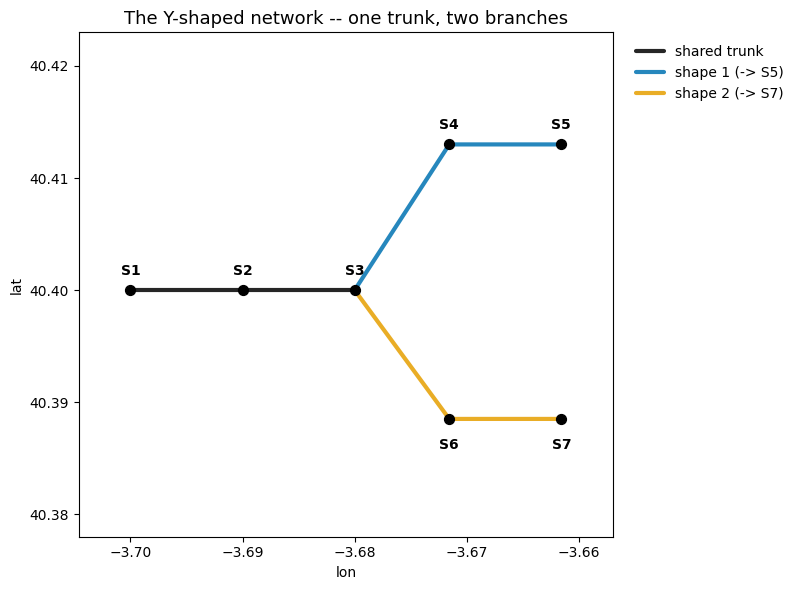

In [29]:
fig, ax = plt.subplots(figsize=(7.5, 6))
plot_network(
    ax, STOP_COORDS,
    [(trunk, CB_BLACK, "shared trunk"), (branch1, CB_BLUE, "shape 1 (-> S5)"), (branch2, CB_ORANGE, "shape 2 (-> S7)")],
    title="The Y-shaped network -- one trunk, two branches", lower_labels=lower_branch,
)
ax.set_ylim(40.378, 40.423)
plt.tight_layout()
plt.show()

## 2. Naive: headway by `route_id`

* both shapes every 10 min, offset 5 min -> true combined headway at trunk = 5 min
* `by="route_id"` groups by `route_id` (+ `direction_id`) -- incidental to geometry

In [30]:
def trunk_headway_by_route(dirname):
    feed = Feed(str(Y_DIR / dirname))
    hw = feed.get_headway_at_stops(WINDOW_DATE, start_time=START_TIME, end_time=END_TIME, by="route_id", at="parent_station", how="all")
    return hw.filter(pl.col("parent_station").str.starts_with("S2")).select(["route_id", "headway"]).sort("route_id")


print("diff_routes (shape 1 = route L1, shape 2 = route L2):")
print(tidy(trunk_headway_by_route("diff_routes")))
print()
print("same_route (both shapes = route L1):")
print(tidy(trunk_headway_by_route("same_route")))

diff_routes (shape 1 = route L1, shape 2 = route L2):
shape: (2, 2)
┌───────────┬─────────┐
│ route_id  ┆ headway │
│ ---       ┆ ---     │
│ str       ┆ f64     │
╞═══════════╪═════════╡
│ L1_file_0 ┆ 10.0    │
│ L2_file_0 ┆ 10.0    │
└───────────┴─────────┘

same_route (both shapes = route L1):
shape: (1, 2)
┌───────────┬─────────┐
│ route_id  ┆ headway │
│ ---       ┆ ---     │
│ str       ┆ f64     │
╞═══════════╪═════════╡
│ L1_file_0 ┆ 5.0     │
└───────────┴─────────┘


* diff. `route_id` -> 10 min (not combined)
* same `route_id` -> 5 min (combined)
* same network, same schedule -- answer depends on an unrelated data-modeling choice

## 3. Fix: headway by geometric direction

`by="shape_direction"` clusters by bearing, not `route_id`.

In [31]:
def trunk_headway_by_direction(dirname):
    feed = Feed(str(Y_DIR / dirname))
    hw = feed.get_headway_at_stops(WINDOW_DATE, start_time=START_TIME, end_time=END_TIME, by="shape_direction", at="parent_station", how="all", n_divisions=1)
    return hw.filter(pl.col("parent_station").str.starts_with("S2")).select(["shape_direction_id", "shape_ids", "headway"])


for name in ["diff_routes", "same_route"]:
    print(f"{name}:")
    print(tidy(trunk_headway_by_direction(name)))
    print()

diff_routes:
shape: (1, 3)
┌────────────────────┬────────────────────────┬─────────┐
│ shape_direction_id ┆ shape_ids              ┆ headway │
│ ---                ┆ ---                    ┆ ---     │
│ i32                ┆ list[str]              ┆ f64     │
╞════════════════════╪════════════════════════╪═════════╡
│ 1                  ┆ ["shape 1", "shape 2"] ┆ 5.0     │
└────────────────────┴────────────────────────┴─────────┘

same_route:
shape: (1, 3)
┌────────────────────┬────────────────────────┬─────────┐
│ shape_direction_id ┆ shape_ids              ┆ headway │
│ ---                ┆ ---                    ┆ ---     │
│ i32                ┆ list[str]              ┆ f64     │
╞════════════════════╪════════════════════════╪═════════╡
│ 1                  ┆ ["shape 1", "shape 2"] ┆ 5.0     │
└────────────────────┴────────────────────────┴─────────┘



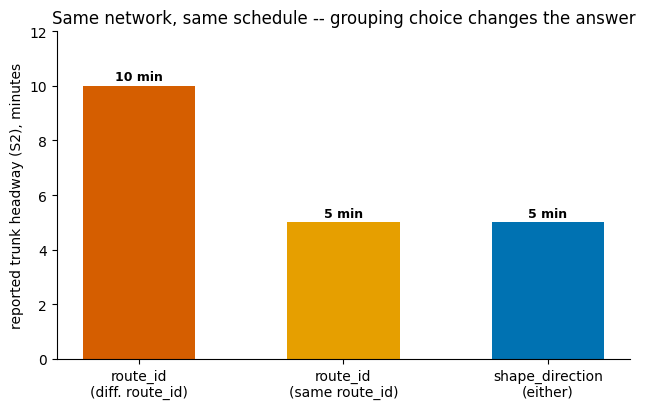

In [32]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
plot_headway_bar(
    ax,
    labels=["route_id\n(diff. route_id)", "route_id\n(same route_id)", "shape_direction\n(either)"],
    values=[10.0, 5.0, 5.0],
    colors=[CB_VERMILLION, CB_ORANGE, CB_BLUE],
    title="Same network, same schedule -- grouping choice changes the answer",
    ylabel="reported trunk headway (S2), minutes", ylim=(0, 12), fmt="{:.0f} min",
)
plt.tight_layout()
plt.show()

* `route_id`: right by luck or wrong by luck
* `shape_direction`: always 5 min -- derived from geometry, not route numbering

## 4. How direction clustering works

### 4.1 Forward/backward correction

* fwd/bwd bearings at a stop should be exactly 180° apart, rarely are
* `_reconcile_fwd_bwd`: rotate both toward each other equally until they are

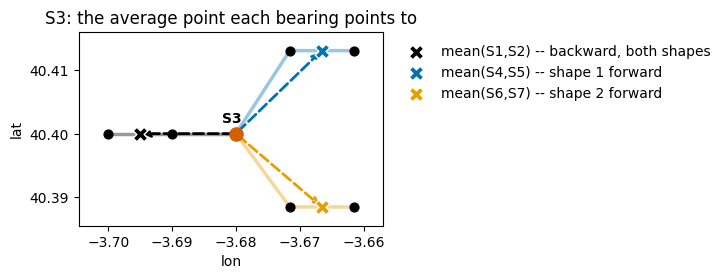

In [33]:
def mean_point(stop_ids):
    lons = [STOP_COORDS[s][0] for s in stop_ids]
    lats = [STOP_COORDS[s][1] for s in stop_ids]
    return sum(lons) / len(lons), sum(lats) / len(lats)


mean_points = [
    ("mean(S1,S2) -- backward, both shapes", CB_BLACK, mean_point(["S1", "S2"])),
    ("mean(S4,S5) -- shape 1 forward", CB_BLUE, mean_point(["S4", "S5"])),
    ("mean(S6,S7) -- shape 2 forward", CB_ORANGE, mean_point(["S6", "S7"])),
]

fig, ax = plt.subplots(figsize=(7.5, 6))
plot_mean_point_map(
    ax, STOP_COORDS, [(trunk, CB_BLACK, None), (branch1, CB_BLUE, None), (branch2, CB_ORANGE, None)],
    hub_id="S3", mean_points=mean_points, title="S3: the average point each bearing points to",
    lower_labels=lower_branch, show_stop_labels=False,
)
plt.tight_layout()
plt.show()

In [34]:
feed_diff = Feed(str(Y_DIR / "diff_routes"))
s3_bearings = (
    feed_diff.shapes.stop_shapes.filter(pl.col("stop_id") == "S3_file_0")
    .select(["shape_id", "shape_direction", "shape_direction_backwards"])
    .collect()
    .sort("shape_id")
)
print(tidy(s3_bearings, round_floats=1))

shape: (2, 3)
┌──────────┬─────────────────┬───────────────────────────┐
│ shape_id ┆ shape_direction ┆ shape_direction_backwards │
│ ---      ┆ ---             ┆ ---                       │
│ str      ┆ f64             ┆ f64                       │
╞══════════╪═════════════════╪═══════════════════════════╡
│ shape 1  ┆ 38.2            ┆ 270.0                     │
│ shape 2  ┆ 138.3           ┆ 270.0                     │
└──────────┴─────────────────┴───────────────────────────┘


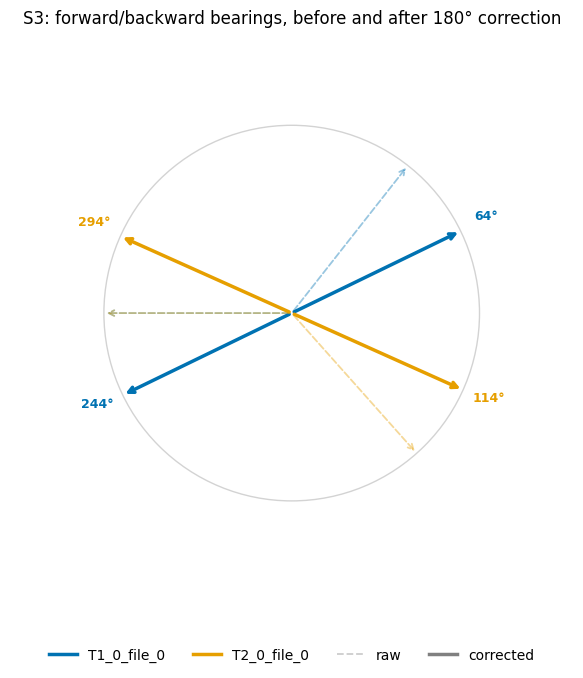

In [35]:
fig, ax = plt.subplots(figsize=(6, 6.5), subplot_kw={"aspect": "equal"})
bearings_by_shape = {row["shape_id"]: (row["shape_direction"], row["shape_direction_backwards"]) for row in s3_bearings.iter_rows(named=True)}
plot_bearing_correction(fig, ax, bearings_by_shape, shape_colors, _reconcile_fwd_bwd)
ax.set_title("S3: forward/backward bearings, before and after 180° correction", fontsize=12)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

* backward bearings (dashed) ≈ identical (shared segment to `S2`)
* forward bearings (solid) ≈ 100° apart -- genuinely different branches
* correction rotates each by ~25-30° to force exactly 180° apart

### 4.2 Widest-gap split

* pool every shape's fwd+bwd point on the circle
* find the widest gap, split at its midpoint

$$
\text{boundary} = \theta_i + \frac{\theta_{i+1}-\theta_i}{2}, \quad i=\underset{i}{\arg\max}(\theta_{i+1}-\theta_i)
$$

for sorted bearings $\theta_1 < \dots < \theta_n$ ($\theta_{n+1}=\theta_1+360\degree$). Both fwd *and* bwd per shape -> a shape's own two directions never land in the same bin.

In [36]:
corrected = {row["shape_id"]: _reconcile_fwd_bwd(row["shape_direction"], row["shape_direction_backwards"]) for row in s3_bearings.iter_rows(named=True)}
split = _split_angle(corrected)
bins = _widest_gap_split(corrected)
print("corrected bearings:", corrected)
print("split angle:", round(split, 1))
print("bins:", bins)

corrected bearings: {'T1_0_file_0': [64.10582519073813, 244.10582519073813], 'T2_0_file_0': [114.1520159559191, 294.15201595591907]}
split angle: 179.1
bins: {'T1_0_file_0': 1, 'T2_0_file_0': 1}


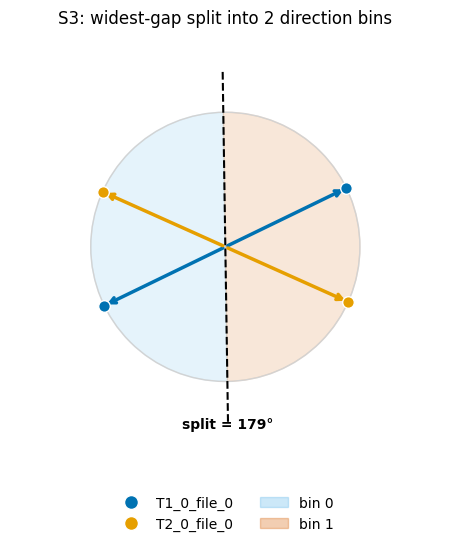

In [37]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"aspect": "equal"})
plot_widest_gap_circle(ax, corrected, split, shape_colors)
ax.set_title("S3: widest-gap split into 2 direction bins", fontsize=12)
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()

### 4.3 Generalizing to *n* directions

`n_divisions=k` -> $2k$ sectors, same split boundary:

$$
\text{sector}(\theta) = \left\lfloor \frac{(\theta - \text{split}\bmod 360\degree)\cdot 2k}{360\degree} \right\rfloor
$$

($k$ even -> boundary offset by $90\degree/k$.) $k=1$ = the 2-bin case above.

widest-gap split angle: 90.0


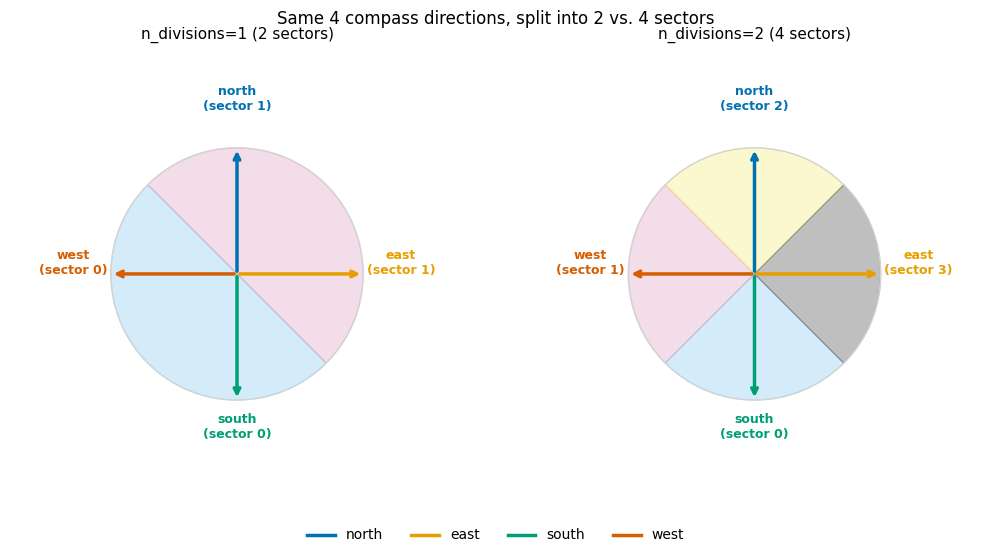

In [38]:
demo_bearings_pairs = {"north": [0.0, 180.0], "east": [90.0, 270.0], "south": [180.0, 0.0], "west": [270.0, 90.0]}
demo_split = geo_polars.max_separation_angle(pl.DataFrame({"a": [list(v) for v in demo_bearings_pairs.values()]}), "a")[0]
print("widest-gap split angle:", demo_split)

demo_bearings = {"north": 0.0, "east": 90.0, "south": 180.0, "west": 270.0}
demo_colors = {"north": CB_BLUE, "east": CB_ORANGE, "south": CB_GREEN, "west": CB_VERMILLION}

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.5), subplot_kw={"aspect": "equal"})
# demo_split lands exactly on the "east" point here (a tie, since all 4
# points are exactly 90 degrees apart) -- +45 bisects one of the tied
# widest gaps instead, rather than sitting degenerately on a point.
plot_sector_split(axes[0], demo_bearings, demo_colors, demo_split + 45, n_divisions=1, title="n_divisions=1 (2 sectors)", show_labels=True)
plot_sector_split(axes[1], demo_bearings, demo_colors, demo_split, n_divisions=2, title="n_divisions=2 (4 sectors)", show_labels=True)
fig.suptitle("Same 4 compass directions, split into 2 vs. 4 sectors", fontsize=12)

handles = [plt.Line2D([0], [0], color=color, lw=2.5, label=label) for label, color in demo_colors.items()]
fig.legend(handles=handles, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.06))
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

* 2 sectors: north+east merge, south+west merge -- wrong
* 4 sectors: each direction distinct

### 4.4 Split line, every stop

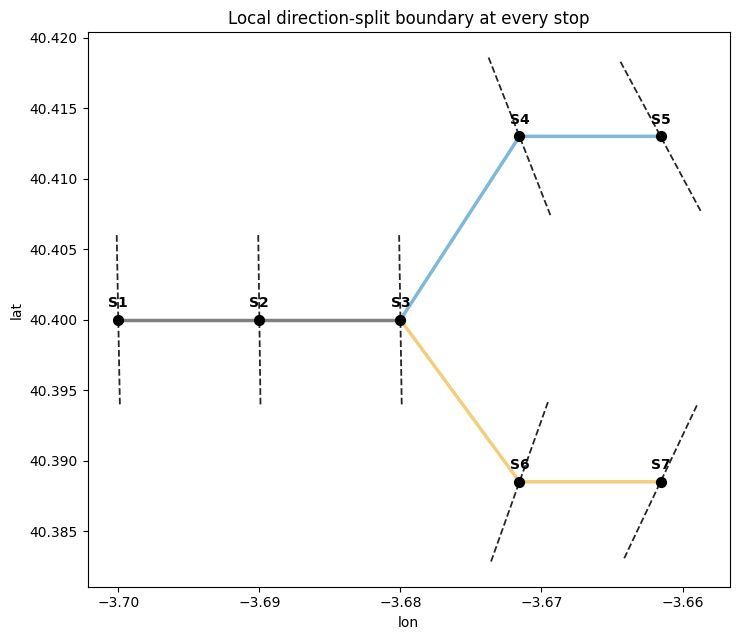

In [39]:
all_bearings = (
    feed_diff.shapes.stop_shapes.select(["stop_id", "shape_id", "shape_direction", "shape_direction_backwards"])
    .collect()
)

split_by_stop = {}
for stop_id in STOP_COORDS:
    sub = all_bearings.filter(pl.col("stop_id") == f"{stop_id}_file_0")
    bearings = {}
    for row in sub.iter_rows(named=True):
        angles = _reconcile_fwd_bwd(row["shape_direction"], row["shape_direction_backwards"])
        if angles:
            bearings[row["shape_id"]] = angles
    split_by_stop[stop_id] = _split_angle(bearings) if bearings else None

fig, ax = plt.subplots(figsize=(7.5, 6.5))
plot_split_line_network(
    ax, STOP_COORDS, [(trunk, CB_BLACK, None), (branch1, CB_BLUE, None), (branch2, CB_ORANGE, None)],
    split_by_stop, title="Local direction-split boundary at every stop",
)
plt.tight_layout()
plt.show()

## 5. Headway formula

$$
g_0 = (d_1-\text{start}) + (\text{end}-d_n)
$$

$$
\text{headway} = \frac{g_0^2 + \sum_{i=1}^{n-1}(d_{i+1}-d_i)^2}{\text{end}-\text{start}}
$$

* not a plain average of gaps -- weights long gaps more (inspection paradox: random arrival more likely lands in a long gap)

In [40]:
start, end = 0, 3600
regular = np.arange(0, 3600, 600)          # bus every 10 min, like clockwork
irregular = np.array([0, 100, 1100, 1200, 2900, 3000])  # same 6 buses, badly bunched

print("regular  :", compute_headway(regular, start, end) / 60, "min")
print("irregular:", compute_headway(irregular, start, end) / 60, "min")

regular  : 10.0 min
irregular: 19.814814814814817 min


* same buses, same average gap -- bunched schedule scores worse (larger headway)

### 5.1 One branch each, 10 min

`S4`/`S5` and `S6`/`S7`: single shape each -> 10 min, nothing to combine.

In [41]:
hw_diff = feed_diff.get_headway_at_stops(WINDOW_DATE, start_time=START_TIME, end_time=END_TIME, by="shape_direction", at="parent_station", how="all", n_divisions=1)
branch_view = (
    hw_diff.with_columns(pl.col("parent_station").str.replace("_file_0", "").alias("stop"))
    .select(["stop", "shape_ids", "headway"])
    .sort("stop")
)
print(tidy(branch_view))

shape: (5, 3)
┌──────┬────────────────────────┬─────────┐
│ stop ┆ shape_ids              ┆ headway │
│ ---  ┆ ---                    ┆ ---     │
│ str  ┆ list[str]              ┆ f64     │
╞══════╪════════════════════════╪═════════╡
│ S1   ┆ ["shape 1", "shape 2"] ┆ 5.0     │
│ S2   ┆ ["shape 1", "shape 2"] ┆ 5.0     │
│ S3   ┆ ["shape 2", "shape 1"] ┆ 5.0     │
│ S4   ┆ ["shape 1"]            ┆ 10.0    │
│ S6   ┆ ["shape 2"]            ┆ 10.0    │
└──────┴────────────────────────┴─────────┘


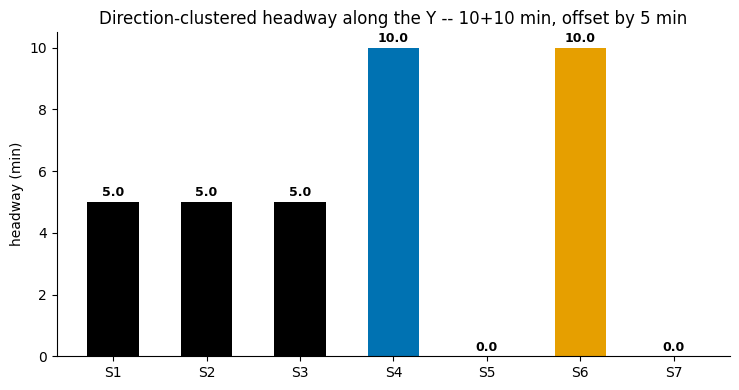

In [42]:
order = ["S1", "S2", "S3", "S4", "S5", "S6", "S7"]
vals = {r["stop"]: r["headway"] for r in branch_view.iter_rows(named=True)}
colors_bar = [CB_BLUE if s in ("S4", "S5") else (CB_ORANGE if s in ("S6", "S7") else CB_BLACK) for s in order]

fig, ax = plt.subplots(figsize=(7.5, 4))
plot_headway_bar(
    ax, labels=order, values=[vals.get(s, 0) for s in order], colors=colors_bar,
    title="Direction-clustered headway along the Y -- 10+10 min, offset by 5 min",
)
plt.tight_layout()
plt.show()

### 5.2 Irregular branch headway: 10 and 20 min

Shape 2 now every 20 min (still offset 5 min). Trunk pools both -- what headway?

In [43]:
feed_mixed = Feed(str(Y_DIR / "mixed_headway"))
hw_mixed = feed_mixed.get_headway_at_stops(WINDOW_DATE, start_time=START_TIME, end_time=END_TIME, by="shape_direction", at="parent_station", how="all", n_divisions=1)
trunk_mixed = hw_mixed.filter(pl.col("parent_station") == "S2_file_0").select(["shape_ids", "headway"])
print(tidy(trunk_mixed))

shape: (1, 2)
┌────────────────────────┬─────────┐
│ shape_ids              ┆ headway │
│ ---                    ┆ ---     │
│ list[str]              ┆ f64     │
╞════════════════════════╪═════════╡
│ ["shape 1", "shape 2"] ┆ 7.5     │
└────────────────────────┴─────────┘


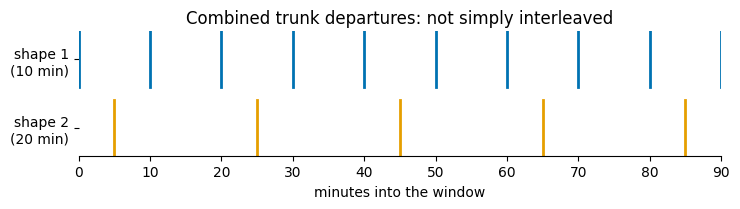

In [44]:
# Reproduce it directly from the formula: T1 every 10 min from t=0,
# T2 every 20 min from t=300s (5 min offset), over the 4-hour window.
start_sec, end_sec = 0, 4 * 3600
t1 = np.arange(0, end_sec, 600)
t2 = np.arange(300, end_sec, 1200)

fig, ax = plt.subplots(figsize=(7.5, 2.2))
plot_departure_timeline(
    ax,
    groups=[("shape 1\n(10 min)", CB_BLUE, t1, 0.55, 1.0), ("shape 2\n(20 min)", CB_ORANGE, t2, 0.0, 0.45)],
    title="Combined trunk departures: not simply interleaved",
)
ax.set_xlim(0, 90)
plt.tight_layout()
plt.show()

In [45]:
# Closed-form check: since T1's headway (10 min) and T2's headway (20 min)
# share a common multiple, the combined pattern isn't just "irregular" --
# it's exactly periodic with period lcm(10, 20) = 20 minutes, repeating the
# gaps [5, 5, 10] forever (departures at 0, 5, 10, 20, 25, 30, ...).
repeating_gaps = np.array([5.0, 5.0, 10.0])
closed_form_headway = (repeating_gaps ** 2).sum() / repeating_gaps.sum()
print("repeating gap pattern (min):", repeating_gaps.tolist())
print("plain average gap:", repeating_gaps.mean(), "min")
print("Σgap² / Σgap (closed form):", closed_form_headway, "min")

repeating gap pattern (min): [5.0, 5.0, 10.0]
plain average gap: 6.666666666666667 min
Σgap² / Σgap (closed form): 7.5 min


* **7.5 min**, smaller than either alone (pooling = more frequent, expected)
* not the naive average (15)
* not $1/(1/h_1+1/h_2)=6.67$ (that assumes random phase; here phase is fixed)
* pattern repeats every lcm(10,20)=20 min with gaps 5,5,10:

$$
\frac{5^2+5^2+10^2}{5+5+10} = 7.5
$$

## 6. S3: 2 vs 4 vs 6 directions

A plain shared-trunk Y (sections 1-5) can *never* separate its two branches, however wide their angle at `S3` -- both reconcile against the exact same backward bearing (the shared trunk), capping their corrected separation just under 90°. Same `S3`, same `corrected`/`split` from 4.2, at `n_divisions=1/2/3`.

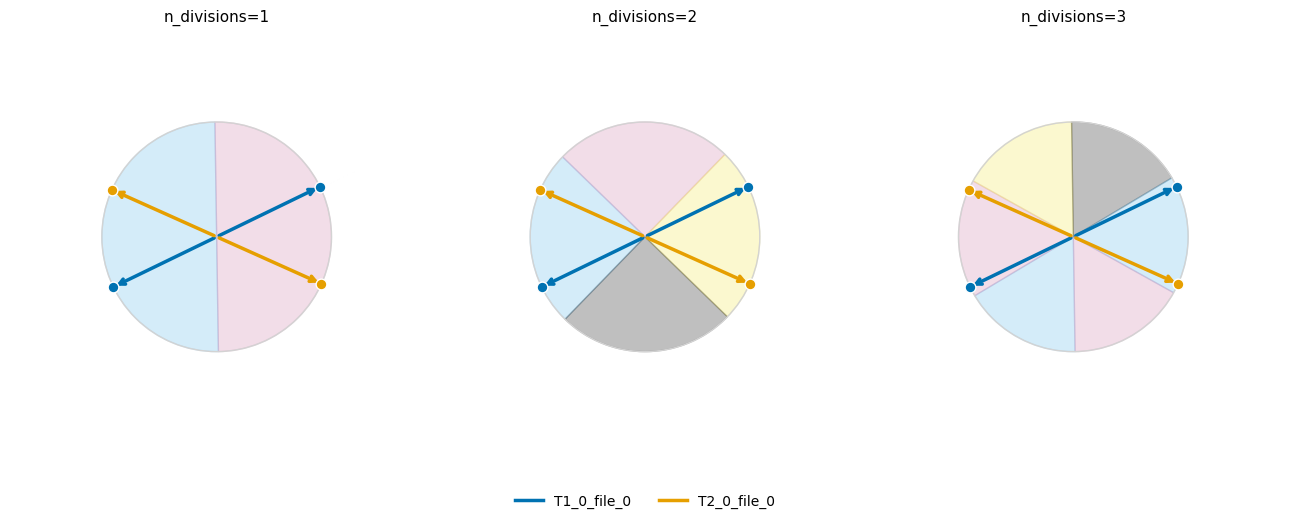

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5), subplot_kw={"aspect": "equal"})
corrected_points = {f"{shape_id}_{i}": angle for shape_id, angles in corrected.items() for i, angle in enumerate(angles)}
corrected_point_colors = {f"{shape_id}_{i}": shape_colors[shape_id] for shape_id, angles in corrected.items() for i in range(len(angles))}
plot_sector_split(axes[0], corrected_points, corrected_point_colors, split, n_divisions=1, title="n_divisions=1")
plot_sector_split(axes[1], corrected_points, corrected_point_colors, split, n_divisions=2, title="n_divisions=2")
plot_sector_split(axes[2], corrected_points, corrected_point_colors, split, n_divisions=3, title="n_divisions=3")

handles = [plt.Line2D([0], [0], color=color, lw=2.5, label=shape_id) for shape_id, color in shape_colors.items()]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.05))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [47]:
for nd in (1, 2, 3):
    hw = feed_mixed.get_headway_at_stops(WINDOW_DATE, start_time=START_TIME, end_time=END_TIME, by="shape_direction", at="parent_station", how="all", n_divisions=nd)
    row = hw.filter(pl.col("parent_station") == "S3_file_0")
    print(f"n_divisions={nd}: {row.height} bin(s), headway={row['headway'].to_list()}")

n_divisions=1: 1 bin(s), headway=[7.5]
n_divisions=2: 1 bin(s), headway=[7.5]
n_divisions=3: 1 bin(s), headway=[7.5]


* both shapes' bearings sit in the same half-circle -- 2, 4, and 6 sectors all give the same, single, combined bin (7.5 min)
* `n_divisions` cannot fix a stop where the branches genuinely aren't separated enough -- see 6.1 for what actually does

### 6.1 `method`: how the 180° correction is distributed

`_reconcile_fwd_bwd(fwd, bwd, method=...)`:

* `"both"` (default): split the correction between forward and backward equally
* `"forward"`: trust forward as-is, backward absorbs the full correction
* `"backward"`: trust backward as-is, forward absorbs the full correction

Two more shapes at `S3`, same plain Y as sections 1-5: shape 3 is the exact reverse of shape 1, shape 4 the exact reverse of shape 2.

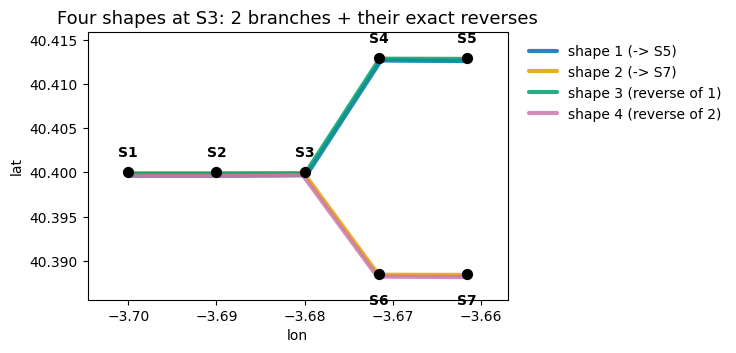

In [48]:
from tests.example_gtfs import build_y_shape_four

Y_FOUR_DIR = Path("test_files/y_shape/four")
build_y_shape_four(Y_FOUR_DIR, headway1=600, headway2=1200, headway3=900, headway4=1800)
feed_four = Feed(str(Y_FOUR_DIR))

four_shape_colors = {"T1_0_file_0": CB_BLUE, "T2_0_file_0": CB_ORANGE, "T3_0_file_0": CB_GREEN, "T4_0_file_0": CB_PURPLE}
four_branches = [
    (["S1", "S2", "S3", "S4", "S5"], CB_BLUE, "shape 1 (-> S5)"),
    (["S1", "S2", "S3", "S6", "S7"], CB_ORANGE, "shape 2 (-> S7)"),
    (["S5", "S4", "S3", "S2", "S1"], CB_GREEN, "shape 3 (reverse of 1)"),
    (["S7", "S6", "S3", "S2", "S1"], CB_PURPLE, "shape 4 (reverse of 2)"),
]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
plot_network(ax, STOP_COORDS, four_branches, title="Four shapes at S3: 2 branches + their exact reverses", lower_labels=lower_branch, lane_offset=0.00025)
plt.tight_layout()
plt.show()

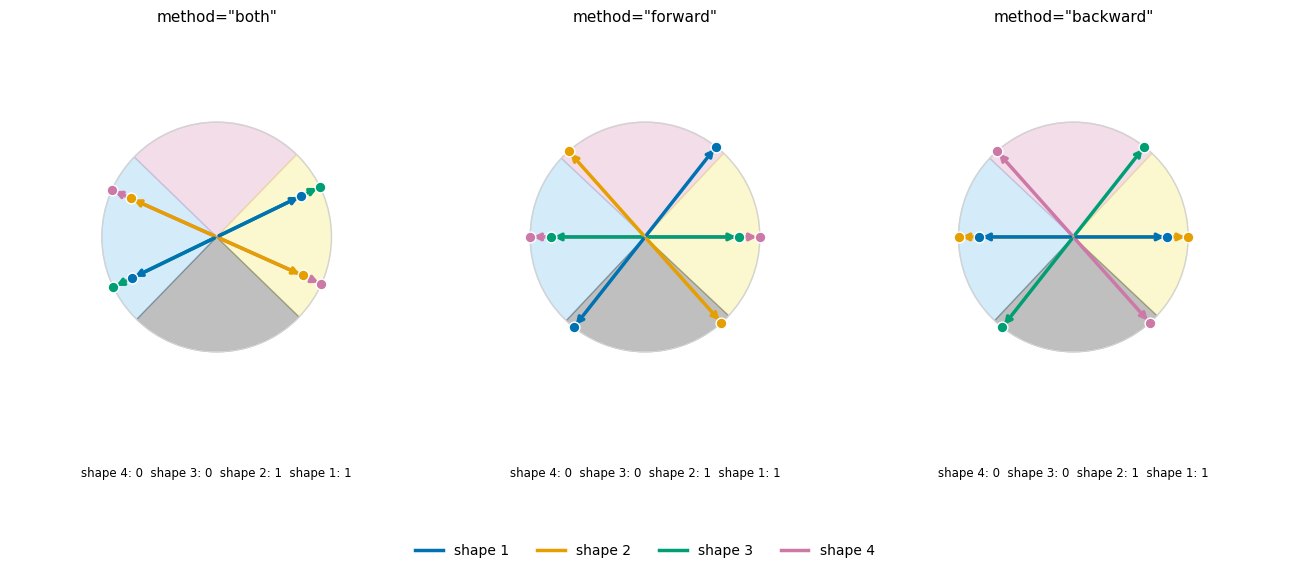

In [49]:
s3_four_bearings = (
    feed_four.shapes.stop_shapes.filter(pl.col("stop_id") == "S3_file_0")
    .select(["shape_id", "shape_direction", "shape_direction_backwards"])
    .collect()
)
raw_bearings_four = {row["shape_id"]: (row["shape_direction"], row["shape_direction_backwards"]) for row in s3_four_bearings.iter_rows(named=True)}

four_shape_names = {"T1_0_file_0": "shape 1", "T2_0_file_0": "shape 2", "T3_0_file_0": "shape 3", "T4_0_file_0": "shape 4"}

fig, axes = plt.subplots(1, 3, figsize=(13, 6), subplot_kw={"aspect": "equal"})
for ax, method in zip(axes, ["both", "forward", "backward"]):
    corrected_m = {sid: _reconcile_fwd_bwd(fwd, bwd, method=method) for sid, (fwd, bwd) in raw_bearings_four.items()}
    split_m = _split_angle(corrected_m)
    bins_m = _widest_gap_split(corrected_m)
    points_m = {f"{sid}_{i}": angle for sid, angles in corrected_m.items() for i, angle in enumerate(angles)}
    colors_m = {f"{sid}_{i}": four_shape_colors[sid] for sid, angles in corrected_m.items() for i in range(len(angles))}
    named_bins_m = {four_shape_names[sid]: b for sid, b in bins_m.items()}
    plot_sector_split(ax, points_m, colors_m, split_m, n_divisions=2, title=f'method="{method}"', direction_ids=named_bins_m)

handles = [plt.Line2D([0], [0], color=color, lw=2.5, label=four_shape_names[sid]) for sid, color in four_shape_colors.items()]
fig.legend(handles=handles, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.05))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

* with all 4 shapes present, the widest gap now separates **outbound** (shapes 1+2, direction 0) from **inbound** (shapes 3+4, direction 1) -- and all three methods agree on that split
* shape 3's forward bearing *is* shape 1's backward bearing (same physical line, opposite direction) -- adding the reverse trips fills in exactly the points that made `"both"`/`"backward"` cap out at 90° in the 2-shape case, so the method choice stops mattering here
* `method` matters most when a stop only sees one direction of travel per branch (few shapes); with enough shapes pooled, the geometry itself pins the split down regardless of method

### 6.2 `how`: all vs. best vs. add

Sector $i$ and sector $i+n\_divisions$ are diametrically opposite -- the
*same* physical road, outbound vs. inbound, not two different
destinations. `get_headway_at_stops` tags this with

```
shape_direction_group_id = shape_direction_id % n_divisions
```

so opposite sectors always share one `group_id`. `how` decides what to
do with that:

* `"all"` (used everywhere above): ignores the grouping, returns every
  sector's own headway as its own row
* `"best"`: collapses the *whole station* to one row -- the single
  smallest headway across every sector, any direction
* `"add"` (`mix_directions=False`, the default): first picks the best
  headway *within* each `group_id` (so outbound/inbound never get
  combined with each other), then harmonic-combines *across* groups

Four shapes at `S3`, `n_divisions=2`: shapes 1+2 (outbound) land in one
sector at 7.5 min, shapes 3+4 (inbound) in another at 11.7 min -- both
share `group_id=0` (opposite ends of one road).

In [50]:
for how in ("all", "best", "add"):
    hw_how = feed_four.get_headway_at_stops(WINDOW_DATE, start_time=START_TIME, end_time=END_TIME, by="shape_direction", at="parent_station", how=how, n_divisions=2, direction_method="forward")
    row = hw_how.filter(pl.col("parent_station") == "S3_file_0")
    print(f'how="{how}":')
    cols = [c for c in ["shape_direction_group_id", "shape_ids", "headway"] if c in row.columns]
    print(tidy(row.select(cols)))
    print()

how="all":
shape: (3, 3)
┌──────────────────────────┬────────────────────────┬─────────┐
│ shape_direction_group_id ┆ shape_ids              ┆ headway │
│ ---                      ┆ ---                    ┆ ---     │
│ i32                      ┆ list[str]              ┆ f64     │
╞══════════════════════════╪════════════════════════╪═════════╡
│ 1                        ┆ ["shape 1"]            ┆ 10.0    │
│ 0                        ┆ ["shape 3", "shape 4"] ┆ 11.67   │
│ 1                        ┆ ["shape 2"]            ┆ 20.0    │
└──────────────────────────┴────────────────────────┴─────────┘

how="best":
shape: (1, 2)
┌─────────────┬─────────┐
│ shape_ids   ┆ headway │
│ ---         ┆ ---     │
│ list[str]   ┆ f64     │
╞═════════════╪═════════╡
│ ["shape 1"] ┆ 10.0    │
└─────────────┴─────────┘

how="add":
shape: (1, 2)
┌─────────────────────────────────┬─────────┐
│ shape_ids                       ┆ headway │
│ ---                             ┆ ---     │
│ list[str]               

With `direction_method="forward"`, shapes 1 and 2's raw (uncorrected) bearings are far enough apart to land in *different* sectors -- now there are genuinely two route-groups at `S3`: `group_id=0` (shapes 3+4, 11.7 min) and `group_id=1` (shapes 1 and 2, separately 10 and 20 min).

* `"all"`: every sector's own headway, three rows -- 10, 20, 11.7 min
* `"best"`: collapses to **10 min** -- the single smallest number station-wide, regardless of which group it came from
* `"add"`: **5.4 min** -- picks the best *within* each group first (group 1: min(10, 20)=10; group 0: 11.7), then harmonic-combines *across* the two groups: $1/(1/10 + 1/11.7) = 5.4$. Unlike `"best"`, this treats groups 0 and 1 as two genuinely different, combinable services -- but never blends shapes 1 and 2 *within* group 1, since only one of them is a real alternative for a rider there.

## 7. Real feed: Sevilla headway map

TUSSAM, direction-clustered headway per station, dark = frequent.

In [51]:
import folium
import branca.colormap as bcm

SEVILLA_DIR = "test_files/sevilla/TUSSAM/20260630_120028_TUSSAM"
sevilla_date = datetime.date(2026, 7, 7)  # a Tuesday within the feed's service calendar

feed_sevilla = Feed(SEVILLA_DIR)
hw_sevilla = feed_sevilla.get_headway_at_stops(
    sevilla_date,
    start_time=datetime.time(7, 0),
    end_time=datetime.time(9, 0),
    by="shape_direction",
    at="parent_station",
    how="all",
    n_divisions=1,
)
hw_sevilla = feed_sevilla.add_stop_coords(hw_sevilla).drop_nulls(["stop_lat", "stop_lon"])
print(tidy(hw_sevilla.select(["stop_name", "headway", "route_ids"]).sort("headway").head()))

/home/miguel/Documents/Proyectos/pyGTFSHandler/pyGTFSHandler/models/stop_times.py:182: UserWarning: Some departure times are null and have been interpolated
  warnings.warn("Some departure times are null and have been interpolated")
/home/miguel/Documents/Proyectos/pyGTFSHandler/pyGTFSHandler/models/shapes.py:1312: RuntimeWarning: direction_id assignment: 14 of 487 shape_ids (2.9%) had at least one stop where the geometry disagreed with their reported direction_id (direction_conflict=True), across 15 of 1041 stop(s) (1.4%).
  warnings.warn(


shape: (5, 3)
┌─────────────────────────────────┬─────────┬─────────────────────────────────┐
│ stop_name                       ┆ headway ┆ route_ids                       │
│ ---                             ┆ ---     ┆ ---                             │
│ str                             ┆ f64     ┆ list[str]                       │
╞═════════════════════════════════╪═════════╪═════════════════════════════════╡
│ Enramadilla_(Apeadero_San_Bern… ┆ 3.02    ┆ ["22_file_0", "133_file_0", … … │
│ Avenida_de_Andalucia_(Los_Arco… ┆ 3.13    ┆ ["119_file_0", "22_file_0", … … │
│ Sor_Francisca_Dorotea_(Bda._La… ┆ 3.19    ┆ ["14_file_0", "13_file_0", … "… │
│ Avenida_Llanes_(Miraflores)     ┆ 3.28    ┆ ["2_file_0", "1_file_0", … "16… │
│ Resolana_(Feria)                ┆ 3.31    ┆ ["81_file_0", "83_file_0", … "… │
└─────────────────────────────────┴─────────┴─────────────────────────────────┘


In [52]:
colormap = bcm.LinearColormap(
    colors=[CB_BLUE, CB_SKY, CB_YELLOW, CB_ORANGE, CB_VERMILLION],
    vmin=hw_sevilla["headway"].quantile(0.05),
    vmax=hw_sevilla["headway"].quantile(0.95),
    caption="Peak-hour headway (minutes, direction-clustered)",
)

mean_lat, mean_lon = hw_sevilla["stop_lat"].mean(), hw_sevilla["stop_lon"].mean()
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=13, tiles="CartoDB positron")

for row in hw_sevilla.iter_rows(named=True):
    folium.CircleMarker(
        location=[row["stop_lat"], row["stop_lon"]],
        radius=4,
        color=colormap(row["headway"]),
        fill=True,
        fill_color=colormap(row["headway"]),
        fill_opacity=0.85,
        weight=0.5,
        popup=f"{row['parent_station']}: {row['headway']:.1f} min",
    ).add_to(m)

colormap.add_to(m)

OUTPUT_DIR = Path("outputs/y_shape_headway")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
m.save(str(OUTPUT_DIR / "sevilla_headway_map.html"))
m

[output too large to embed in the docs site -- run this notebook locally or in Colab to view it]

* dark markers = high-frequency trunk stops
* direction-clustered, not `route_id`/`direction_id`-based -- same fix as the synthetic example